<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Goal" data-toc-modified-id="Goal-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Goal</a></span></li><li><span><a href="#Var" data-toc-modified-id="Var-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Var</a></span></li><li><span><a href="#Init" data-toc-modified-id="Init-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Init</a></span></li><li><span><a href="#Load" data-toc-modified-id="Load-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Load</a></span></li><li><span><a href="#EnvFit" data-toc-modified-id="EnvFit-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>EnvFit</a></span><ul class="toc-item"><li><span><a href="#setup" data-toc-modified-id="setup-5.1"><span class="toc-item-num">5.1&nbsp;&nbsp;</span>setup</a></span></li><li><span><a href="#Study-condition" data-toc-modified-id="Study-condition-5.2"><span class="toc-item-num">5.2&nbsp;&nbsp;</span>Study condition</a></span></li><li><span><a href="#Disease" data-toc-modified-id="Disease-5.3"><span class="toc-item-num">5.3&nbsp;&nbsp;</span>Disease</a></span><ul class="toc-item"><li><span><a href="#Disease-vs-healthy" data-toc-modified-id="Disease-vs-healthy-5.3.1"><span class="toc-item-num">5.3.1&nbsp;&nbsp;</span>Disease vs healthy</a></span></li></ul></li><li><span><a href="#Westernized" data-toc-modified-id="Westernized-5.4"><span class="toc-item-num">5.4&nbsp;&nbsp;</span>Westernized</a></span></li><li><span><a href="#Gender" data-toc-modified-id="Gender-5.5"><span class="toc-item-num">5.5&nbsp;&nbsp;</span>Gender</a></span></li><li><span><a href="#Age" data-toc-modified-id="Age-5.6"><span class="toc-item-num">5.6&nbsp;&nbsp;</span>Age</a></span></li><li><span><a href="#Westernized-&amp;-Gender" data-toc-modified-id="Westernized-&amp;-Gender-5.7"><span class="toc-item-num">5.7&nbsp;&nbsp;</span>Westernized &amp; Gender</a></span></li><li><span><a href="#Westerinzed-+-gender-+-age-+-bmi" data-toc-modified-id="Westerinzed-+-gender-+-age-+-bmi-5.8"><span class="toc-item-num">5.8&nbsp;&nbsp;</span>Westerinzed + gender + age + bmi</a></span></li><li><span><a href="#Westerinzed-+-gender-+-age-+-disease" data-toc-modified-id="Westerinzed-+-gender-+-age-+-disease-5.9"><span class="toc-item-num">5.9&nbsp;&nbsp;</span>Westerinzed + gender + age + disease</a></span></li></ul></li><li><span><a href="#sessionInfo" data-toc-modified-id="sessionInfo-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>sessionInfo</a></span></li></ul></div>

# Goal

* EnvFit analysis with environmental variables

# Var

In [58]:
# working dir
work_dir = '/ebio/abt3_projects/databases_no-backup/curatedMetagenomicData/global_metagenomes/diversity/'

# bracken counts
brk_file = '/ebio/abt3_projects/databases_no-backup/curatedMetagenomicData/global_metagenomes/diversity/bracken_filt.qs'

# metadata
## filtered
metadata_filt_file = file.path(work_dir, 'CurMetDat_metadata_filt-n1846.tsv')
## all 
base_in_dir = '/ebio/abt3_projects/small_projects/nyoungblut/public_data_retireval/'
metadata_file = file.path(base_in_dir, 'CurMetDat-metagenomes', 'files', 'metadata', 'Filtered_CurMetDat_f.tsv')

# params
threads = 8

# Init

In [59]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(data.table)
library(tidytable)
library(ape)
library(phyloseq)
library(vegan)
library(LeyLabRMisc)

In [60]:
df.dims()
setDTthreads(threads)
make_dir(work_dir)

Directory already exists: /ebio/abt3_projects/databases_no-backup/curatedMetagenomicData/global_metagenomes/diversity/ 


# Load

In [61]:
# loading PCoA objects
F = '/ebio/abt3_projects/databases_no-backup/curatedMetagenomicData/global_metagenomes/diversity/beta-div_pcoa.qs'
brk_cls_pcoa_objA = qs::qread(F, nthreads=4)
names(brk_cls_pcoa_objA) =  c('bray', 'jaccard', 'wunifrac_phy', 'unifrac_phy')

F = '/ebio/abt3_projects/databases_no-backup/curatedMetagenomicData/global_metagenomes/diversity/beta-div_trt-maj_pcoa.qs'
brk_cls_pcoa_objB = qs::qread(F, nthreads=4)
names(brk_cls_pcoa_objB) =  c('wunifrac_trt', 'unifrac_trt')

In [62]:
# loading PCoA objects
F = '/ebio/abt3_projects/databases_no-backup/curatedMetagenomicData/global_metagenomes/diversity/beta-div_cog_pcoa.qs'
brk_cls_pcoa_objC = qs::qread(F, nthreads=4)
names(brk_cls_pcoa_objC) =  c('wunifrac_cog', 'unifrac_cog')

F = '/ebio/abt3_projects/databases_no-backup/curatedMetagenomicData/global_metagenomes/diversity/beta-div_cogcat_pcoa.qs'
brk_cls_pcoa_objD = qs::qread(F, nthreads=4)
names(brk_cls_pcoa_objD) =  c('wunifrac_cogcat', 'unifrac_cogcat')

In [63]:
# loading PCoA objects
F = '/ebio/abt3_projects/databases_no-backup/curatedMetagenomicData/global_metagenomes/diversity/beta-div_pfam_pcoa.qs'
brk_cls_pcoa_objE = qs::qread(F, nthreads=4)
names(brk_cls_pcoa_objE) =  c('wunifrac_pfam', 'unifrac_pfam')

F = '/ebio/abt3_projects/databases_no-backup/curatedMetagenomicData/global_metagenomes/diversity/beta-div_pfamcat_pcoa.qs'
brk_cls_pcoa_objF = qs::qread(F, nthreads=4)
names(brk_cls_pcoa_objF) =  c('wunifrac_pfamcat', 'unifrac_pfamcat')

In [64]:
# combining lists
brk_cls_pcoa_obj = do.call(c, list(brk_cls_pcoa_objA, brk_cls_pcoa_objB,
                                   brk_cls_pcoa_objC, brk_cls_pcoa_objD,
                                   brk_cls_pcoa_objE, brk_cls_pcoa_objF))
brk_cls_pcoa_objA = brk_cls_pcoa_objB = NULL
brk_cls_pcoa_objC = brk_cls_pcoa_objD = NULL
brk_cls_pcoa_objE = brk_cls_pcoa_objF = NULL
brk_cls_pcoa_obj %>% names

[1] "bray"             "jaccard"          "wunifrac_phy"     "unifrac_phy"     
 [5] "wunifrac_trt"     "unifrac_trt"      "wunifrac_cog"     "unifrac_cog"     
 [9] "wunifrac_cogcat"  "unifrac_cogcat"   "wunifrac_pfam"    "unifrac_pfam"    
[13] "wunifrac_pfamcat" "unifrac_pfamcat"

In [65]:
# metadata
meta = Fread(metadata_file) %>%
    mutate.(Sample = gsub('-', '.', Sample))
meta

Warning message in require_bit64_if_needed(ans):
“Some columns are type 'integer64' but package bit64 is not installed. Those columns will print as strange looking floating point data. There is no need to reload the data. Simply install.packages('bit64') to obtain the integer64 print method and print the data again.”


dataset_name,Sample,subjectID,body_site,antibiotics_current_use,study_condition,disease,age,age_category,gender,⋯,il_1,glp_1,travel_destination,urea_nitrogen,disease_stage,uncurated_metadata,family_member,subject_n,samp_n,westernized
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,⋯,<dbl>,<dbl>,<chr>,<dbl>,<int>,<chr>,<chr>,<int>,<int>,<lgl>
AsnicarF_2017,MV_FEM1_t1Q14,MV_FEM1,stool,NA,control,healthy,NA,adult,female,⋯,NA,NA,NA,NA,NA,NA,NA,1,1,TRUE
AsnicarF_2017,MV_FEM2_t1Q14,MV_FEM2,stool,NA,control,healthy,NA,adult,female,⋯,NA,NA,NA,NA,NA,NA,NA,1,1,TRUE
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋱,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
ZellerG_2014,CCIS82944710ST.20.0,FR-730,stool,NA,control,healthy,38,adult,female,⋯,NA,NA,NA,NA,NA,NA,NA,1,1,TRUE
ZellerG_2014,CCIS93040568ST.20.0,FR-682,stool,NA,control,healthy,65,adult,male,⋯,NA,NA,NA,NA,NA,NA,NA,1,1,TRUE


In [66]:
# checking overlap of sample IDs
overlap(meta$Sample, rownames(brk_cls_pcoa_obj[[1]]$points))

intersect(x,y): 3348 
setdiff(x,y): 246 
setdiff(y,x): 0 
union(x,y): 3594 


In [67]:
brk_cls_pcoa_obj[[1]] %>% names

[1] "points" "eig"    "x"      "ac"     "GOF"

In [68]:
brk_cls_pcoa_obj[[1]]$points %>% head

A01_02_1FE,-0.1916428,-0.00903594,0.1371302,-0.2073115,0.1320674
A02_01_1FE,-0.2831024,0.12195303,0.2382405,-0.2453668,0.1016621
⋮,⋮,⋮,⋮,⋮,⋮
A04_04_1FE,-0.4267506,0.08416375,0.05064138,-0.003934785,0.1202795
A05_01_1FE,-0.2880595,-0.04475535,0.19598818,-0.096560918,0.1504658


# EnvFit

## setup

In [69]:
#' envfit in parallel 
#' @return data.frame
envFit = function(col_idx, env, pcoa, perm=9, choices=c(1,2)){
    x = intersect(rownames(pcoa$points), rownames(env))
    E = env[x,col_idx,drop=FALSE]
    E[,1] = E[,1] %>% as.factor %>% as.numeric %>% scale
    pcoa$points = pcoa$points[x,]
    fit = vegan::envfit(pcoa, E, perm = perm, choices=choices, na.rm=TRUE)
    fit = data.frame((fit$vectors)$arrows, (fit$vectors)$r, (fit$vectors)$pvals)
    return(fit)
}

In [70]:
#' envfit in parallel
envfit_parallel = function(pcoa, env, nperm=99, threads=1, choices=c(1,2)){
    doParallel::registerDoParallel(threads)
    fit = 1:ncol(env) %>% as.list %>%
        plyr::llply(envFit, env=env, pcoa=pcoa, perm=nperm, 
                    choices=choices, .parallel=threads > 1) %>%
        do.call(rbind, .) %>%
        mutate(name = rownames(.)) %>%
        rename('r2' = X.fit.vectors..r,
               'pval' = X.fit.vectors..pvals) %>%
        mutate(pval = pval %>% as.Num,
               qval = pval %>% p.adjust)
    return(fit)
}

In [71]:
# number of permutations
nperm=99

## Study condition

In [72]:
# creating env object 
env = meta %>%
    filter.(!is.na(study_condition),
              study_condition != 'control') %>%
    select.(Sample, study_condition) %>%
    as.data.frame
rownames(env) = env$Sample
env$Sample = NULL
env

,study_condition
,<chr>
LD.Run2.17,infectiousgastroenteritis
SAMEA104335965,melanoma
⋮,⋮
SAM_19,melanoma
SAM_17,melanoma


In [73]:
# envfit: top PC
specFit = brk_cls_pcoa_obj %>%
    lapply(envfit_parallel, env=env, nperm=999, choices=1:2, threads=threads) %>%
    data.table::rbindlist(use.names=TRUE, idcol='distance') %>%
    as_tibble %>%
    group_by(distance) %>%
    mutate(r2_rank = row_number(-r2)) %>%
    ungroup() %>%
    gather(Dim, Dim_value, Dim1, Dim2)
specFit

distance,r2,pval,name,qval,r2_rank,Dim,Dim_value
<chr>,<dbl>,<dbl>,<chr>,<dbl>,<int>,<chr>,<dbl>
bray,0.02829557,0.001,study_condition,0.001,1,Dim1,-0.6395251
jaccard,0.03280204,0.001,study_condition,0.001,1,Dim1,-0.5048252
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
wunifrac_pfamcat,0.005488154,0.196,study_condition,0.196,1,Dim2,0.3279480
unifrac_pfamcat,0.052332673,0.001,study_condition,0.001,1,Dim2,-0.5772108


In [74]:
# significant?
specFit %>%
    filter(qval < 0.05)

distance,r2,pval,name,qval,r2_rank,Dim,Dim_value
<chr>,<dbl>,<dbl>,<chr>,<dbl>,<int>,<chr>,<dbl>
bray,0.02829557,0.001,study_condition,0.001,1,Dim1,-0.6395251
jaccard,0.03280204,0.001,study_condition,0.001,1,Dim1,-0.5048252
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
unifrac_pfam,0.05332706,0.001,study_condition,0.001,1,Dim2,0.6069390
unifrac_pfamcat,0.05233267,0.001,study_condition,0.001,1,Dim2,-0.5772108


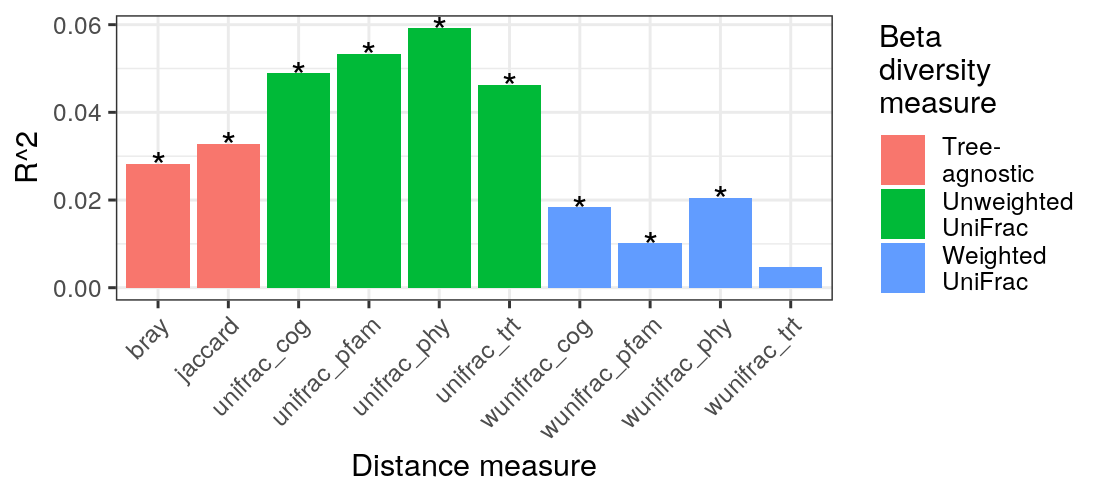

In [75]:
# plotting
p = specFit %>%
    mutate(tree = case_when(grepl('^unifrac', distance) ~ 'Unweighted\nUniFrac',
                            grepl('^wunifrac', distance) ~ 'Weighted\nUniFrac',
                            TRUE ~ 'Tree-\nagnostic')) %>%
    filter(!grepl('cat$', distance)) %>%
    filter(Dim == 'Dim1') %>%
    mutate(qval = ifelse(qval < 0.05, '*', ''),
           Dim = gsub('Dim', 'PC', Dim)) %>%
    ggplot(aes(distance, r2, fill=tree)) +
    geom_bar(stat='identity', position='dodge') +
    geom_text(aes(y=r2, label=qval), size=5, vjust=0.6) +
    scale_fill_discrete('Beta\ndiversity\nmeasure') +
    labs(x='Distance measure', y='R^2') +
    theme_bw() +
    theme(
        axis.text.x = element_text(angle=45, hjust=1)
    )

p.dims(5.5,2.5)
plot(p)

## Disease

In [76]:
# creating env object 
env = meta %>%
    filter.(!is.na(disease), 
            disease != 'healthy') %>%
    select.(Sample, disease) %>%
    as.data.frame
rownames(env) = env$Sample
env$Sample = NULL
env$disease %>% table
env

.
                            ACVD coeliac;gestational_diabetes;CMV 
                             214                                2 
                     fatty_liver         fatty_liver;hypertension 
                              91                               13 
                 fatty_liver;T2D     fatty_liver;T2D;hypertension 
                               3                                9 
                       hepatitis                     hypertension 
                               3                              163 
                             IGT        infectiousgastroenteritis 
                              49                                1 
             melanoma;metastases               metabolic_syndrome 
                              64                                3 
                            STEC                              T2D 
                              43                               53 
                T2D;hypertension 
                          

,disease
,<chr>
LD.Run2.17,infectiousgastroenteritis
SID31009,fatty_liver;hypertension
⋮,⋮
SAM_19,melanoma;metastases
SAM_17,melanoma;metastases


In [77]:
# envfit: top PC
specFit = brk_cls_pcoa_obj %>%
    lapply(envfit_parallel, env=env, nperm=999, choices=1:2, threads=threads) %>%
    data.table::rbindlist(use.names=TRUE, idcol='distance') %>%
    as_tibble %>%
    group_by(distance) %>%
    mutate(r2_rank = row_number(-r2)) %>%
    ungroup() %>%
    gather(Dim, Dim_value, Dim1, Dim2)
specFit

distance,r2,pval,name,qval,r2_rank,Dim,Dim_value
<chr>,<dbl>,<dbl>,<chr>,<dbl>,<int>,<chr>,<dbl>
bray,0.01649028,0.007,disease,0.007,1,Dim1,-0.6663106
jaccard,0.01988812,0.002,disease,0.002,1,Dim1,-0.4976278
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
wunifrac_pfamcat,0.003311397,0.364,disease,0.364,1,Dim2,-0.1524512
unifrac_pfamcat,0.044327021,0.001,disease,0.001,1,Dim2,-0.5974932


In [78]:
# significant?
specFit %>%
    filter(qval < 0.05)

distance,r2,pval,name,qval,r2_rank,Dim,Dim_value
<chr>,<dbl>,<dbl>,<chr>,<dbl>,<int>,<chr>,<dbl>
bray,0.01649028,0.007,disease,0.007,1,Dim1,-0.6663106
jaccard,0.01988812,0.002,disease,0.002,1,Dim1,-0.4976278
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
unifrac_pfam,0.04523933,0.001,disease,0.001,1,Dim2,0.6213275
unifrac_pfamcat,0.04432702,0.001,disease,0.001,1,Dim2,-0.5974932


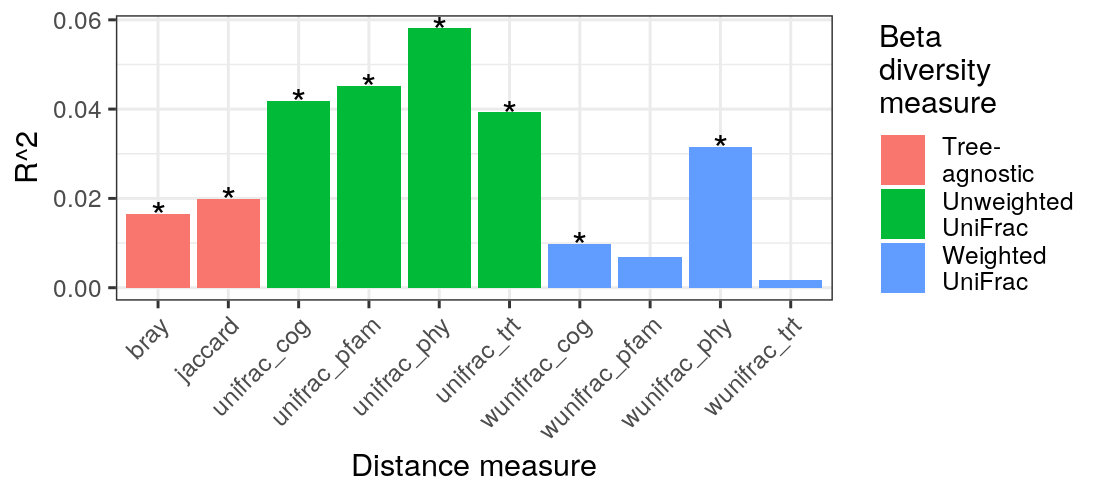

In [79]:
# plotting
p = specFit %>%
    mutate(tree = case_when(grepl('^unifrac', distance) ~ 'Unweighted\nUniFrac',
                            grepl('^wunifrac', distance) ~ 'Weighted\nUniFrac',
                            TRUE ~ 'Tree-\nagnostic')) %>%
    filter(!grepl('cat$', distance)) %>%
    filter(Dim == 'Dim1') %>%
    mutate(qval = ifelse(qval < 0.05, '*', ''),
           Dim = gsub('Dim', 'PC', Dim)) %>%
    ggplot(aes(distance, r2, fill=tree)) +
    geom_bar(stat='identity', position='dodge') +
    geom_text(aes(y=r2, label=qval), size=5, vjust=0.6) +
    scale_fill_discrete('Beta\ndiversity\nmeasure') +
    labs(x='Distance measure', y='R^2') +
    theme_bw() +
    theme(
        axis.text.x = element_text(angle=45, hjust=1)
    )

p.dims(5.5,2.5)
plot(p)

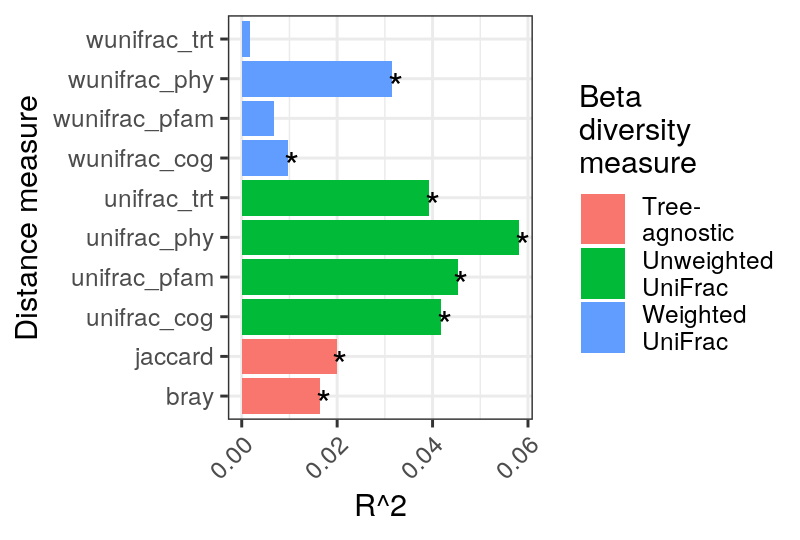

In [80]:
# plotting
p = specFit %>%
    mutate(tree = case_when(grepl('^unifrac', distance) ~ 'Unweighted\nUniFrac',
                            grepl('^wunifrac', distance) ~ 'Weighted\nUniFrac',
                            TRUE ~ 'Tree-\nagnostic')) %>%
    filter(!grepl('cat$', distance)) %>%
    filter(Dim == 'Dim1') %>%
    mutate(qval = ifelse(qval < 0.05, '*', ''),
           Dim = gsub('Dim', 'PC', Dim)) %>%
    ggplot(aes(distance, r2, fill=tree)) +
    geom_bar(stat='identity', position='dodge') +
    geom_text(aes(y=r2, label=qval), size=5, hjust=0.3, vjust=0.8) +
    scale_fill_discrete('Beta\ndiversity\nmeasure') +
    labs(x='Distance measure', y='R^2') +
    theme_bw() +
    theme(
        axis.text.x = element_text(angle=45, hjust=1)
    ) +
    coord_flip()

p.dims(4,2.7)
plot(p)

### Disease vs healthy

In [81]:
# creating env object 
env = meta %>%
    filter.(!is.na(disease)) %>%
    mutate.(disease = ifelse(disease != 'healthy', 'diseased', disease)) %>%
    select.(Sample, disease) %>%
    as.data.frame
rownames(env) = env$Sample
env$Sample = NULL
env$disease %>% table
env

.
diseased  healthy 
     712     2149 

,disease
,<chr>
MV_FEM1_t1Q14,healthy
MV_FEM2_t1Q14,healthy
⋮,⋮
CCIS82944710ST.20.0,healthy
CCIS93040568ST.20.0,healthy


In [82]:
# envfit: top PC
specFit = brk_cls_pcoa_obj %>%
    lapply(envfit_parallel, env=env, nperm=999, choices=1:2, threads=threads) %>%
    data.table::rbindlist(use.names=TRUE, idcol='distance') %>%
    as_tibble %>%
    group_by(distance) %>%
    mutate(r2_rank = row_number(-r2)) %>%
    ungroup() %>%
    gather(Dim, Dim_value, Dim1, Dim2)
specFit

distance,r2,pval,name,qval,r2_rank,Dim,Dim_value
<chr>,<dbl>,<dbl>,<chr>,<dbl>,<int>,<chr>,<dbl>
bray,0.03684771,0.001,disease,0.001,1,Dim1,-0.7364595
jaccard,0.03671238,0.001,disease,0.001,1,Dim1,-0.6430533
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
wunifrac_pfamcat,0.03068776,0.001,disease,0.001,1,Dim2,0.5407620
unifrac_pfamcat,0.09520528,0.001,disease,0.001,1,Dim2,-0.6910578


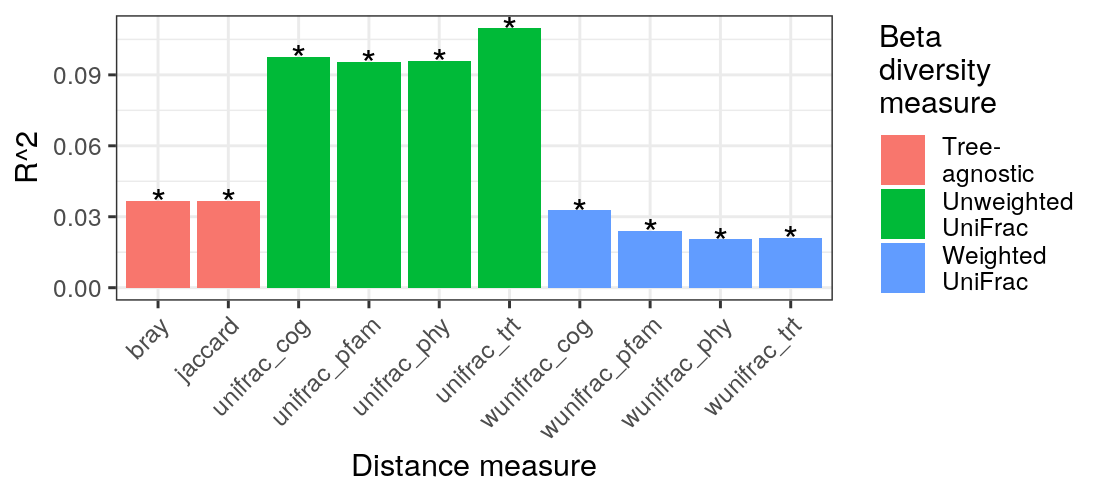

In [83]:
# plotting
p = specFit %>%
    mutate(tree = case_when(grepl('^unifrac', distance) ~ 'Unweighted\nUniFrac',
                            grepl('^wunifrac', distance) ~ 'Weighted\nUniFrac',
                            TRUE ~ 'Tree-\nagnostic')) %>%
    filter(!grepl('cat$', distance)) %>%
    filter(Dim == 'Dim1') %>%
    mutate(qval = ifelse(qval < 0.05, '*', ''),
           Dim = gsub('Dim', 'PC', Dim)) %>%
    ggplot(aes(distance, r2, fill=tree)) +
    geom_bar(stat='identity', position='dodge') +
    geom_text(aes(y=r2, label=qval), size=5, vjust=0.6) +
    scale_fill_discrete('Beta\ndiversity\nmeasure') +
    labs(x='Distance measure', y='R^2') +
    theme_bw() +
    theme(
        axis.text.x = element_text(angle=45, hjust=1)
    )

p.dims(5.5,2.5)
plot(p)

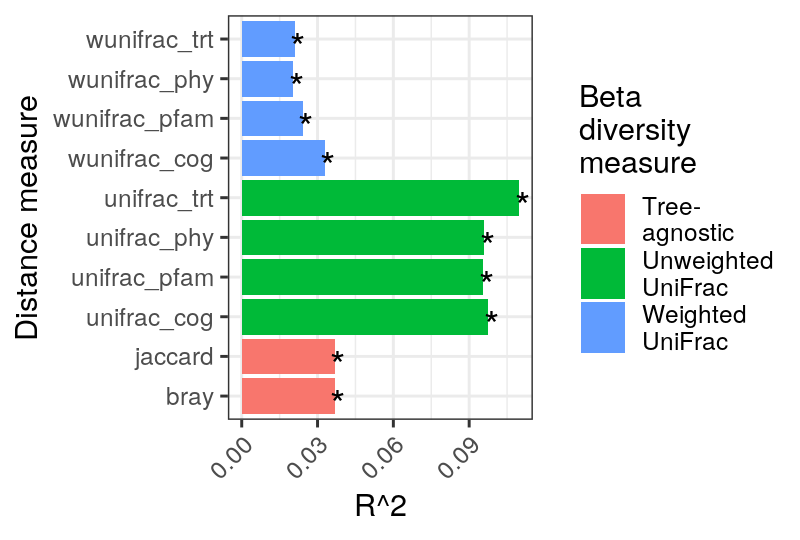

In [84]:
# plotting
p = specFit %>%
    mutate(tree = case_when(grepl('^unifrac', distance) ~ 'Unweighted\nUniFrac',
                            grepl('^wunifrac', distance) ~ 'Weighted\nUniFrac',
                            TRUE ~ 'Tree-\nagnostic')) %>%
    filter(!grepl('cat$', distance)) %>%
    filter(Dim == 'Dim1') %>%
    mutate(qval = ifelse(qval < 0.05, '*', ''),
           Dim = gsub('Dim', 'PC', Dim)) %>%
    ggplot(aes(distance, r2, fill=tree)) +
    geom_bar(stat='identity', position='dodge') +
    geom_text(aes(y=r2, label=qval), size=5, hjust=0.3, vjust=0.8) +
    scale_fill_discrete('Beta\ndiversity\nmeasure') +
    labs(x='Distance measure', y='R^2') +
    theme_bw() +
    theme(
        axis.text.x = element_text(angle=45, hjust=1)
    ) +
    coord_flip()

p.dims(4,2.7)
plot(p)

## Westernized

In [115]:
# creating env object 
env = meta %>%
    filter.(!is.na(westernized)) %>%
    select.(Sample, westernized) %>%
    as.data.frame
rownames(env) = env$Sample
env$Sample = NULL
env

,westernized
,<lgl>
MV_FEM1_t1Q14,TRUE
MV_FEM2_t1Q14,TRUE
⋮,⋮
CCIS82944710ST.20.0,TRUE
CCIS93040568ST.20.0,TRUE


In [116]:
# envfit: top 2 PCs
specFit = brk_cls_pcoa_obj %>%
    lapply(envfit_parallel, env=env, nperm=999, choices=1:2, threads=threads) %>%
    data.table::rbindlist(use.names=TRUE, idcol='distance') %>%
    as_tibble %>%
    group_by(distance) %>%
    mutate(r2_rank = row_number(-r2)) %>%
    ungroup() %>%
    gather(Dim, Dim_value, Dim1, Dim2) # , Dim3, Dim4, Dim5) 
specFit

distance,r2,pval,name,qval,r2_rank,Dim,Dim_value
<chr>,<dbl>,<dbl>,<chr>,<dbl>,<int>,<chr>,<dbl>
bray,0.3116398,0.001,westernized,0.001,1,Dim1,0.9923525
jaccard,0.3053822,0.001,westernized,0.001,1,Dim1,0.9968998
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
wunifrac_pfamcat,0.2751402,0.001,westernized,0.001,1,Dim2,0.19591942
unifrac_pfamcat,0.4242476,0.001,westernized,0.001,1,Dim2,0.03033193


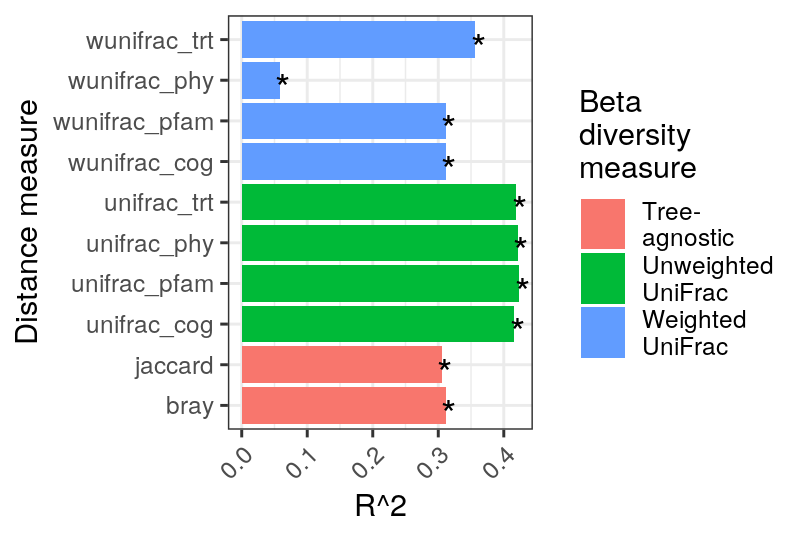

In [117]:
# plotting
p = specFit %>%
    mutate(tree = case_when(grepl('^unifrac', distance) ~ 'Unweighted\nUniFrac',
                            grepl('^wunifrac', distance) ~ 'Weighted\nUniFrac',
                            TRUE ~ 'Tree-\nagnostic')) %>%
    filter(!grepl('cat$', distance)) %>%
    filter(Dim == 'Dim1') %>%
    mutate(qval = ifelse(qval < 0.05, '*', ''),
           Dim = gsub('Dim', 'PC', Dim)) %>%
    ggplot(aes(distance, r2, fill=tree)) +
    geom_bar(stat='identity', position='dodge') +
    geom_text(aes(y=r2, label=qval), size=5, hjust=0.3, vjust=0.8) +
    scale_fill_discrete('Beta\ndiversity\nmeasure') +
    labs(x='Distance measure', y='R^2') +
    theme_bw() +
    theme(
        axis.text.x = element_text(angle=45, hjust=1)
    ) +
    coord_flip()

p.dims(4,2.7)
plot(p)

## Gender

In [118]:
# creating env object 
env = meta %>%
    filter.(!is.na(gender)) %>%
    select.(Sample, gender) %>%
    as.data.frame
rownames(env) = env$Sample
env$Sample = NULL
env

,gender
,<chr>
MV_FEM1_t1Q14,female
MV_FEM2_t1Q14,female
⋮,⋮
CCIS82944710ST.20.0,female
CCIS93040568ST.20.0,male


In [119]:
# envfit: top 2 PCs
specFit = brk_cls_pcoa_obj %>%
    lapply(envfit_parallel, env=env, nperm=999, choices=1:2, threads=threads) %>%
    data.table::rbindlist(use.names=TRUE, idcol='distance') %>%
    as_tibble %>%
    group_by(distance) %>%
    mutate(r2_rank = row_number(-r2)) %>%
    ungroup() %>%
    gather(Dim, Dim_value, Dim1, Dim2) # , Dim3, Dim4, Dim5) 
specFit

distance,r2,pval,name,qval,r2_rank,Dim,Dim_value
<chr>,<dbl>,<dbl>,<chr>,<dbl>,<int>,<chr>,<dbl>
bray,0.01141924,0.001,gender,0.001,1,Dim1,-0.7969895
jaccard,0.01163612,0.001,gender,0.001,1,Dim1,-0.8437551
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
wunifrac_pfamcat,0.002597253,0.063,gender,0.063,1,Dim2,-0.7914032
unifrac_pfamcat,0.046995241,0.001,gender,0.001,1,Dim2,0.9610887


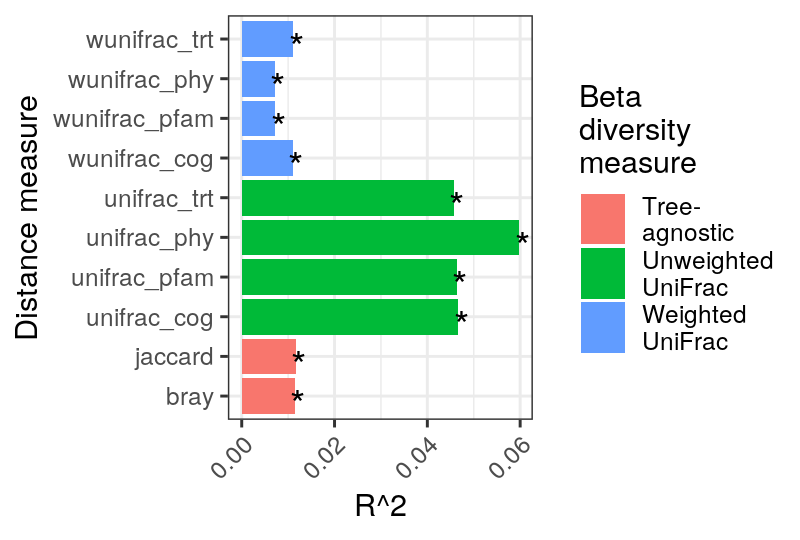

In [120]:
# plotting
p = specFit %>%
    mutate(tree = case_when(grepl('^unifrac', distance) ~ 'Unweighted\nUniFrac',
                            grepl('^wunifrac', distance) ~ 'Weighted\nUniFrac',
                            TRUE ~ 'Tree-\nagnostic')) %>%
    filter(!grepl('cat$', distance)) %>%
    filter(Dim == 'Dim1') %>%
    mutate(qval = ifelse(qval < 0.05, '*', ''),
           Dim = gsub('Dim', 'PC', Dim)) %>%
    ggplot(aes(distance, r2, fill=tree)) +
    geom_bar(stat='identity', position='dodge') +
    geom_text(aes(y=r2, label=qval), size=5, hjust=0.3, vjust=0.8) +
    scale_fill_discrete('Beta\ndiversity\nmeasure') +
    labs(x='Distance measure', y='R^2') +
    theme_bw() +
    theme(
        axis.text.x = element_text(angle=45, hjust=1)
    ) +
    coord_flip()

p.dims(4,2.7)
plot(p)

## Age

In [121]:
# creating env object 
env = meta %>%
    filter.(!is.na(age)) %>%
    select.(Sample, age) %>%
    as.data.frame
rownames(env) = env$Sample
env$Sample = NULL
env

,age
,<int>
TRAVELRES1,25
TRAVELRES10,34
⋮,⋮
CCIS82944710ST.20.0,38
CCIS93040568ST.20.0,65


In [122]:
# envfit: top 2 PCs
specFit = brk_cls_pcoa_obj %>%
    lapply(envfit_parallel, env=env, nperm=999, choices=1:2, threads=threads) %>%
    data.table::rbindlist(use.names=TRUE, idcol='distance') %>%
    as_tibble %>%
    group_by(distance) %>%
    mutate(r2_rank = row_number(-r2)) %>%
    ungroup() %>%
    gather(Dim, Dim_value, Dim1, Dim2) # , Dim3, Dim4, Dim5) 
specFit

distance,r2,pval,name,qval,r2_rank,Dim,Dim_value
<chr>,<dbl>,<dbl>,<chr>,<dbl>,<int>,<chr>,<dbl>
bray,0.02562754,0.001,age,0.001,1,Dim1,0.8921526
jaccard,0.02172892,0.001,age,0.001,1,Dim1,0.9784567
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
wunifrac_pfamcat,0.02274248,0.001,age,0.001,1,Dim2,0.8111536
unifrac_pfamcat,0.05279374,0.001,age,0.001,1,Dim2,-0.7072424


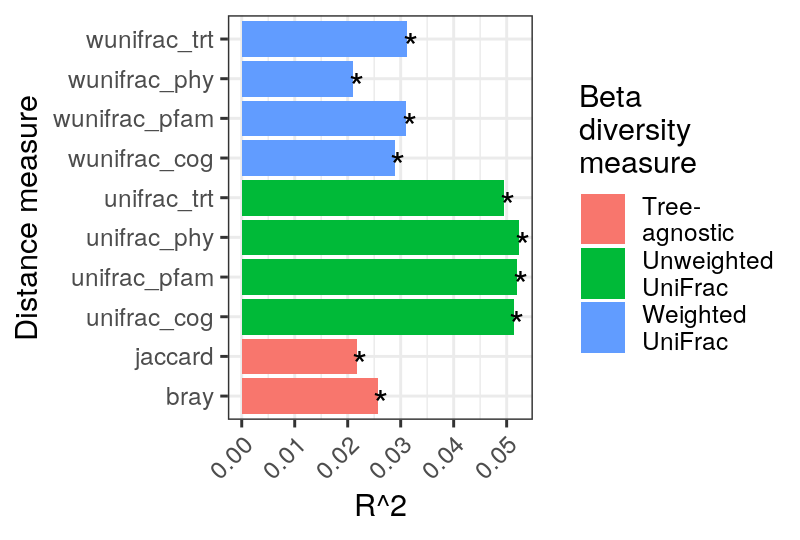

In [123]:
# plotting
p = specFit %>%
    mutate(tree = case_when(grepl('^unifrac', distance) ~ 'Unweighted\nUniFrac',
                            grepl('^wunifrac', distance) ~ 'Weighted\nUniFrac',
                            TRUE ~ 'Tree-\nagnostic')) %>%
    filter(!grepl('cat$', distance)) %>%
    filter(Dim == 'Dim1') %>%
    mutate(qval = ifelse(qval < 0.05, '*', ''),
           Dim = gsub('Dim', 'PC', Dim)) %>%
    ggplot(aes(distance, r2, fill=tree)) +
    geom_bar(stat='identity', position='dodge') +
    geom_text(aes(y=r2, label=qval), size=5, hjust=0.3, vjust=0.8) +
    scale_fill_discrete('Beta\ndiversity\nmeasure') +
    labs(x='Distance measure', y='R^2') +
    theme_bw() +
    theme(
        axis.text.x = element_text(angle=45, hjust=1)
    ) +
    coord_flip()

p.dims(4,2.7)
plot(p)

## Westernized & Gender

In [85]:
# creating env object 
env = meta %>%
    filter.(!is.na(westernized), 
              !is.na(gender)) %>%
    select.(Sample, westernized, gender) %>%
    as.data.frame
rownames(env) = env$Sample
env$Sample = NULL
env

,westernized,gender
,<lgl>,<chr>
MV_FEM1_t1Q14,TRUE,female
MV_FEM2_t1Q14,TRUE,female
⋮,⋮,⋮
CCIS82944710ST.20.0,TRUE,female
CCIS93040568ST.20.0,TRUE,male


In [86]:
# envfit: top 2 PCs
specFit = brk_cls_pcoa_obj %>%
    lapply(envfit_parallel, env=env, nperm=999, choices=1:2, threads=threads) %>%
    data.table::rbindlist(use.names=TRUE, idcol='distance') %>%
    as_tibble %>%
    group_by(distance) %>%
    mutate(r2_rank = row_number(-r2)) %>%
    ungroup() %>%
    gather(Dim, Dim_value, Dim1, Dim2) # , Dim3, Dim4, Dim5) 
specFit

distance,r2,pval,name,qval,r2_rank,Dim,Dim_value
<chr>,<dbl>,<dbl>,<chr>,<dbl>,<int>,<chr>,<dbl>
bray,0.39518636,0.001,westernized,0.002,1,Dim1,0.9873234
bray,0.01141924,0.001,gender,0.002,2,Dim1,-0.7969895
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
unifrac_pfamcat,0.50088564,0.001,westernized,0.002,1,Dim2,-0.0186030
unifrac_pfamcat,0.04699524,0.001,gender,0.002,2,Dim2,0.9610887


In [87]:
# R^2 distribution
specFit %>% summary_x('r2', r2)

,Min.,1st Qu.,Median,Mean,3rd Qu.,Max.,sd,sd_err_of_mean
r2,0.002597253,0.03048236,0.09101271,0.2169913,0.4127481,0.5008856,0.207,0.085


In [88]:
# significant?
specFit %>%
    filter(qval < 0.05)

distance,r2,pval,name,qval,r2_rank,Dim,Dim_value
<chr>,<dbl>,<dbl>,<chr>,<dbl>,<int>,<chr>,<dbl>
bray,0.39518636,0.001,westernized,0.002,1,Dim1,0.9873234
bray,0.01141924,0.001,gender,0.002,2,Dim1,-0.7969895
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
unifrac_pfamcat,0.50088564,0.001,westernized,0.002,1,Dim2,-0.0186030
unifrac_pfamcat,0.04699524,0.001,gender,0.002,2,Dim2,0.9610887


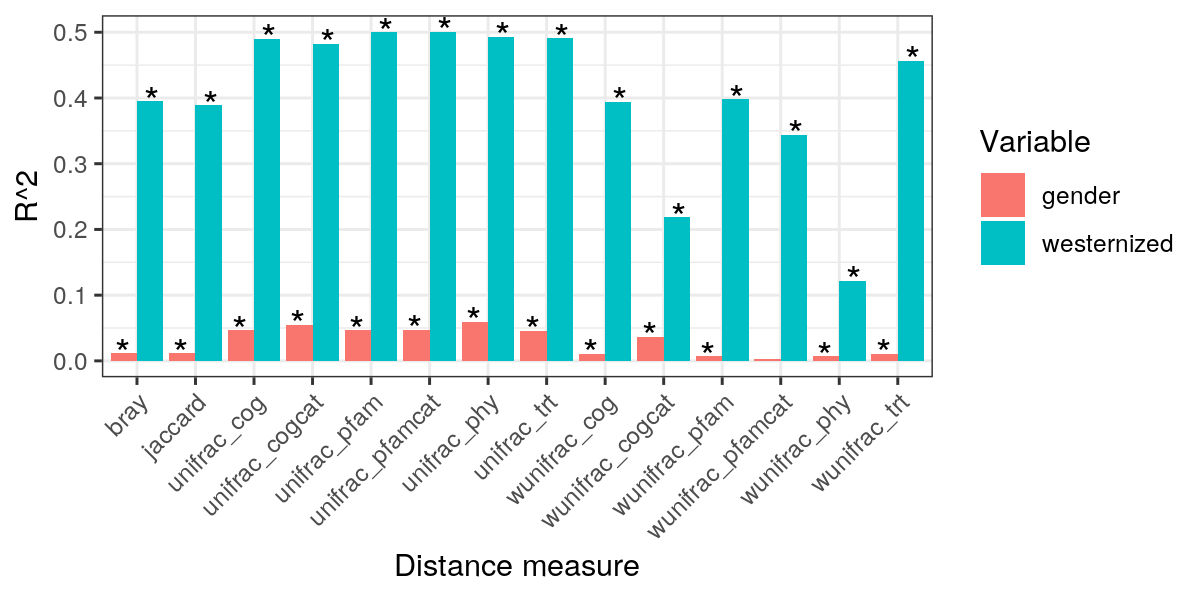

In [89]:
# plotting
p = specFit %>%
    filter(Dim == 'Dim1') %>%
    mutate(qval = ifelse(qval < 0.05, '*', ''),
           Dim = gsub('Dim', 'PC', Dim)) %>%
    ggplot(aes(distance, r2, fill=name)) +
    geom_bar(stat='identity', position='dodge') +
    geom_text(aes(y=r2, label=qval),
              position = position_dodge(width = 1),
              size=5) +
    scale_fill_discrete('Variable') +
    labs(x='Distance measure', y='R^2') +
    theme_bw() +
    theme(
        axis.text.x = element_text(angle=45, hjust=1)
    )

p.dims(6,3)
plot(p)

## Westerinzed + gender + age + bmi

In [90]:
# creating env object 
env = meta %>%
    filter.(!is.na(westernized), 
              !is.na(gender),
              !is.na(age),
              !is.na(BMI)) %>%
    mutate.(age = log2(age),
            BMI = car::bcPower(BMI, -1)) %>%
    select(Sample, westernized, gender, age, BMI) %>%
    as.data.frame
rownames(env) = env$Sample
env$Sample = NULL
env

,westernized,gender,age,BMI
,<lgl>,<chr>,<dbl>,<dbl>
SID713A004.11.0.0,FALSE,female,5.584963,0.9589154
SID713A009.11.90.0,FALSE,male,5.523562,0.9656003
⋮,⋮,⋮,⋮,⋮
CCIS82944710ST.20.0,TRUE,female,5.247928,0.9545455
CCIS93040568ST.20.0,TRUE,male,6.022368,0.9666667


In [91]:
# envfit: top 2 PCs
specFit = brk_cls_pcoa_obj %>%
    lapply(envfit_parallel, env=env, nperm=999, choices=1:2, threads=threads) %>%
    data.table::rbindlist(use.names=TRUE, idcol='distance') %>%
    as_tibble %>%
    group_by(distance) %>%
    mutate(r2_rank = row_number(-r2)) %>%
    ungroup() %>%
    gather(Dim, Dim_value, Dim1, Dim2)#, Dim3, Dim4, Dim5) 
specFit

distance,r2,pval,name,qval,r2_rank,Dim,Dim_value
<chr>,<dbl>,<dbl>,<chr>,<dbl>,<int>,<chr>,<dbl>
bray,0.185026769,0.001,westernized,0.004,1,Dim1,0.9773954
bray,0.008797887,0.015,gender,0.030,3,Dim1,-0.7734896
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
unifrac_pfamcat,0.03206646,0.001,age,0.004,3,Dim2,0.8393625
unifrac_pfamcat,0.01071983,0.007,BMI,0.007,4,Dim2,0.2927998


In [92]:
# summary of adj. p-values
specFit$qval %>% summary_x('q-values')

,Min.,1st Qu.,Median,Mean,3rd Qu.,Max.,sd,sd_err_of_mean
q-values,0.004,0.004,0.004,0.04482143,0.0225,0.495,0.196,0.08


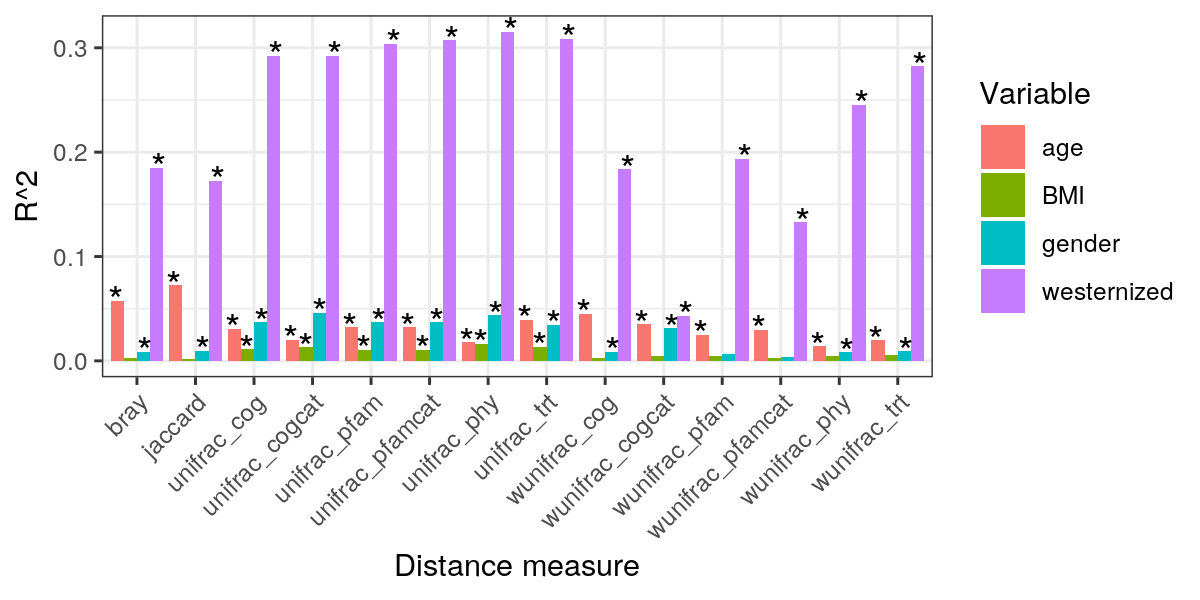

In [93]:
# plotting
p = specFit %>%
    filter(Dim == 'Dim1') %>%
    mutate(qval = ifelse(qval < 0.05, '*', ''),
           Dim = gsub('Dim', 'PC', Dim)) %>%
    ggplot(aes(distance, r2, fill=name)) +
    geom_bar(stat='identity', position='dodge') +
    geom_text(aes(y=r2, label=qval),
              position = position_dodge(width = 1),
              size=5) +
    scale_fill_discrete('Variable') +
    labs(x='Distance measure', y='R^2') +
    theme_bw() +
    theme(
        axis.text.x = element_text(angle=45, hjust=1)
    )

p.dims(6,3)
plot(p)

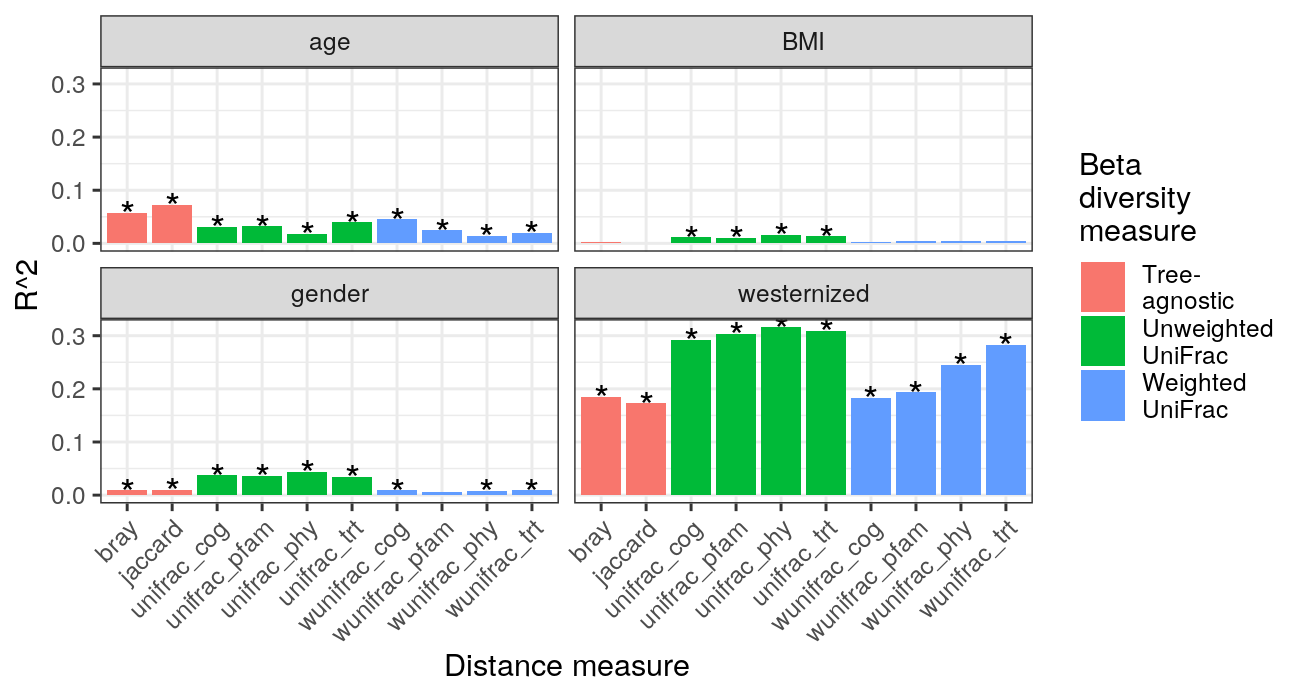

In [94]:
# plotting
p = specFit %>%
    mutate(tree = case_when(grepl('^unifrac', distance) ~ 'Unweighted\nUniFrac',
                            grepl('^wunifrac', distance) ~ 'Weighted\nUniFrac',
                            TRUE ~ 'Tree-\nagnostic')) %>%
    filter(Dim == 'Dim1') %>%
    filter(!grepl('cat$', distance)) %>%
    mutate(qval = ifelse(qval < 0.05, '*', ''),
           Dim = gsub('Dim', 'PC', Dim)) %>%
    ggplot(aes(distance, r2, fill=tree)) +
    geom_bar(stat='identity', position='dodge') +
    geom_text(aes(y=r2, label=qval), size=5, vjust=0.6, color='black') +
    scale_fill_discrete('Beta\ndiversity\nmeasure') +
    labs(x='Distance measure', y='R^2') +
    facet_wrap(~ name) +
    theme_bw() +
    theme(
        axis.text.x = element_text(angle=45, hjust=1)
    )

p.dims(6.5,3.5)
plot(p)

## Westerinzed + gender + age + disease

In [124]:
# creating env object 
env = meta %>%
    mutate.(disease = ifelse(disease != 'healthy', 'diseased', disease)) %>%
    filter.(!is.na(westernized), 
            !is.na(gender),
            !is.na(age),
            !is.na(disease)) %>%
    select.(Sample, westernized, gender, age, disease) %>%
    as.data.frame
rownames(env) = env$Sample
env$Sample = NULL
env

,westernized,gender,age,disease
,<lgl>,<chr>,<int>,<chr>
TRAVELRES1,TRUE,female,25,healthy
TRAVELRES10,TRUE,female,34,healthy
⋮,⋮,⋮,⋮,⋮
CCIS82944710ST.20.0,TRUE,female,38,healthy
CCIS93040568ST.20.0,TRUE,male,65,healthy


In [125]:
# envfit: top 2 PCs
specFit = brk_cls_pcoa_obj %>%
    lapply(envfit_parallel, env=env, nperm=999, choices=1:2, threads=threads) %>%
    data.table::rbindlist(use.names=TRUE, idcol='distance') %>%
    as_tibble %>%
    group_by(distance) %>%
    mutate(r2_rank = row_number(-r2)) %>%
    ungroup() %>%
    gather(Dim, Dim_value, Dim1, Dim2)#, Dim3, Dim4, Dim5) 
specFit

distance,r2,pval,name,qval,r2_rank,Dim,Dim_value
<chr>,<dbl>,<dbl>,<chr>,<dbl>,<int>,<chr>,<dbl>
bray,0.39145606,0.001,westernized,0.004,1,Dim1,0.9750292
bray,0.01232901,0.001,gender,0.004,3,Dim1,-0.1847736
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
unifrac_pfamcat,0.009252438,0.006,age,0.006,4,Dim2,-0.4863025
unifrac_pfamcat,0.076932719,0.001,disease,0.004,2,Dim2,0.4569063


In [126]:
specFit$qval %>% summary_x('q-values')

,Min.,1st Qu.,Median,Mean,3rd Qu.,Max.,sd,sd_err_of_mean
q-values,0.004,0.004,0.004,0.01519643,0.004,0.499,0.201,0.082


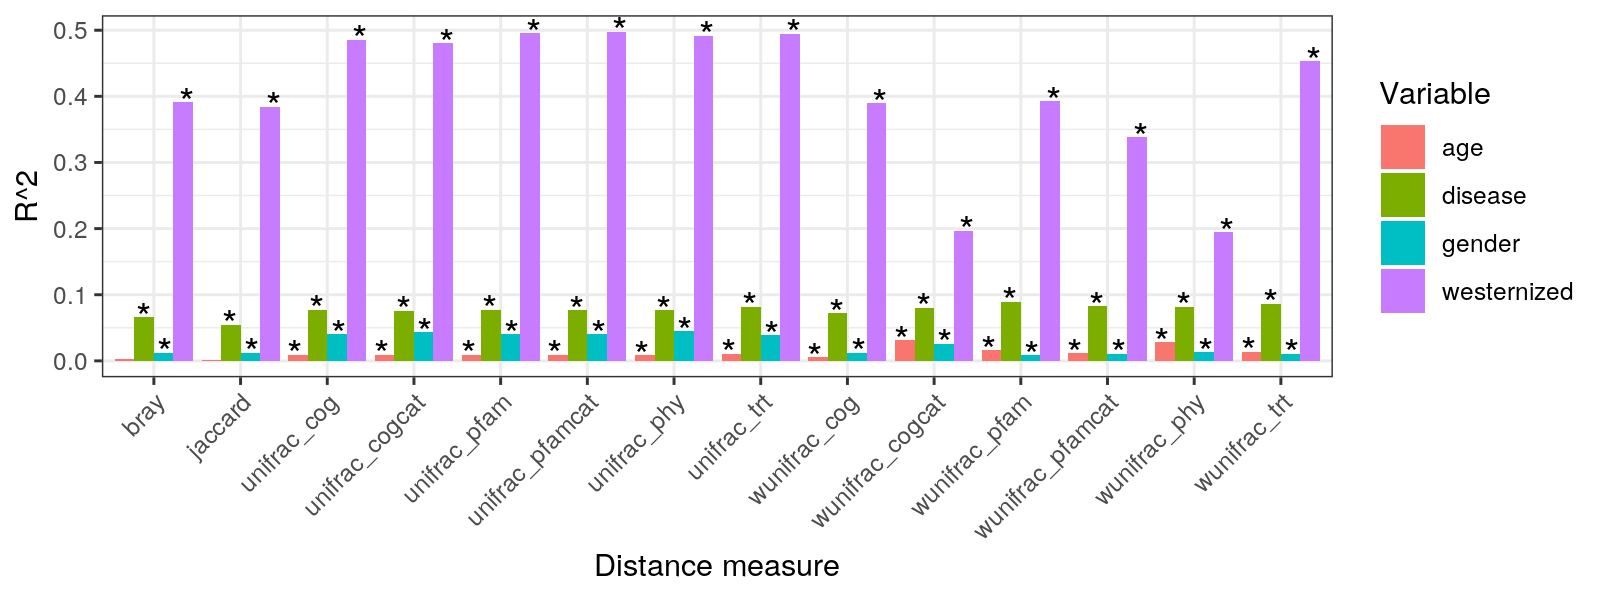

In [127]:
# plotting
p = specFit %>%
    filter(Dim == 'Dim1') %>%
    mutate(qval = ifelse(qval < 0.05, '*', ''),
           Dim = gsub('Dim', 'PC', Dim)) %>%
    ggplot(aes(distance, r2, fill=name)) +
    geom_bar(stat='identity', position='dodge') +
    geom_text(aes(y=r2, label=qval),
              position = position_dodge(width = 1),
              size=5) +
    scale_fill_discrete('Variable') +
    labs(x='Distance measure', y='R^2') +
    theme_bw() +
    theme(
        axis.text.x = element_text(angle=45, hjust=1)
    )

p.dims(8,3)
plot(p)

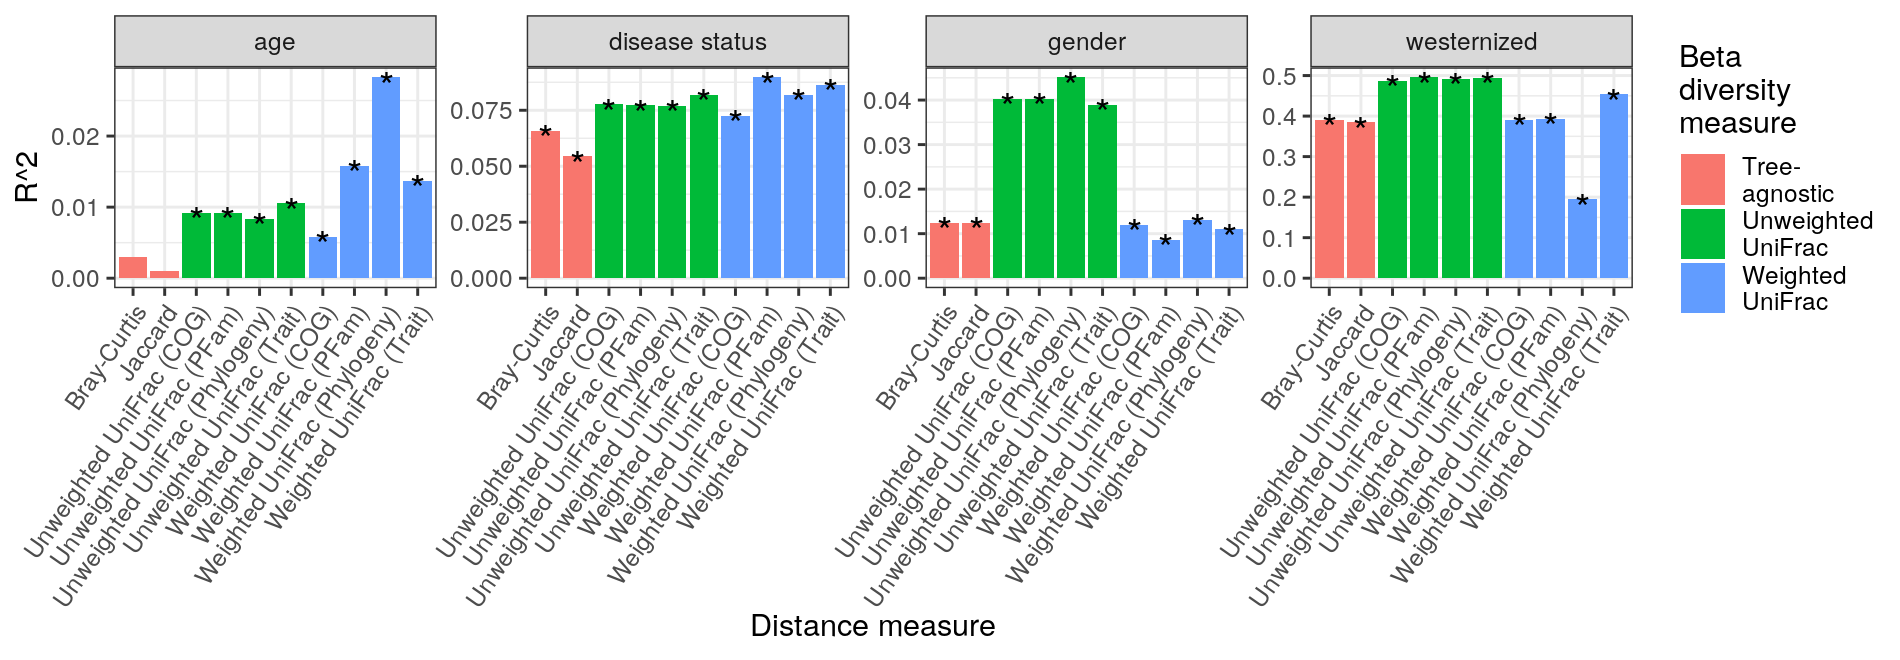

In [133]:
# plotting
p = specFit %>%
    mutate(tree = case_when(grepl('^unifrac', distance) ~ 'Unweighted\nUniFrac',
                            grepl('^wunifrac', distance) ~ 'Weighted\nUniFrac',
                            TRUE ~ 'Tree-\nagnostic')) %>%
    mutate(distance = case_when(distance == 'bray' ~ 'Bray-Curtis',
                                distance == 'jaccard' ~ 'Jaccard',
                                distance == 'unifrac_cog' ~ 'Unweighted UniFrac (COG)',
                                distance == 'unifrac_pfam' ~ 'Unweighted UniFrac (PFam)',
                                distance == 'unifrac_phy' ~ 'Unweighted UniFrac (Phylogeny)',
                                distance == 'unifrac_trt' ~ 'Unweighted UniFrac (Trait)',
                                distance == 'wunifrac_cog' ~ 'Weighted UniFrac (COG)',
                                distance == 'wunifrac_pfam' ~ 'Weighted UniFrac (PFam)',
                                distance == 'wunifrac_phy' ~ 'Weighted UniFrac (Phylogeny)',
                                distance == 'wunifrac_trt' ~ 'Weighted UniFrac (Trait)',
                                TRUE ~ 'Other')) %>%
    filter(distance != 'Other') %>%
    mutate(name = ifelse(name == 'disease', 'disease status', name)) %>%
    filter(Dim == 'Dim1') %>%
    filter(!grepl('cat$', distance)) %>%
    mutate(qval = ifelse(qval < 0.05, '*', ''),
           Dim = gsub('Dim', 'PC', Dim)) %>%
    ggplot(aes(distance, r2, fill=tree)) +
    geom_bar(stat='identity', position='dodge') +
    geom_text(aes(y=r2, label=qval), size=5, vjust=0.8, color='black') +
    scale_fill_discrete('Beta\ndiversity\nmeasure') +
    labs(x='Distance measure', y='R^2') +
    facet_wrap(~ name, scales='free_y', nrow=1) +
    theme_bw() +
    theme(
        axis.text.x = element_text(angle=55, hjust=1)
    )

p.dims(9.5,3.3)
plot(p)

# sessionInfo

In [217]:
sessionInfo()

R version 3.6.3 (2020-02-29)
Platform: x86_64-conda_cos6-linux-gnu (64-bit)
Running under: Ubuntu 18.04.5 LTS

Matrix products: default
BLAS/LAPACK: /ebio/abt3_projects/Georg_animal_feces/envs/phyloseq/lib/libopenblasp-r0.3.9.so

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] LeyLabRMisc_0.1.6 vegan_2.5-6       lattice_0.20-41   permute_0.9-5    
 [5] phyloseq_1.30.0   ape_5.4           tidytable_0.4.1   data.table_1.12.8
 [9] ggplot2_3.3.1     tidyr_1.1.0       dplyr_1.0.0      

loaded via a namespace (and not attached):
 [1] Biobase_2.46.0      b